🎯 Target variable: Target

📊 Model Evaluation Results:

Logistic Regression:
Accuracy:  0.993
Precision: 0.993
Recall:    0.993
F1 Score:  0.993

Random Forest:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000


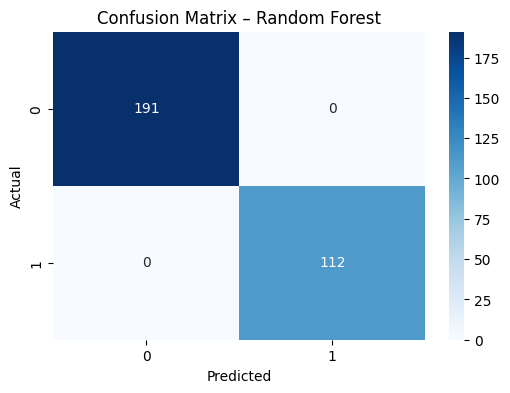

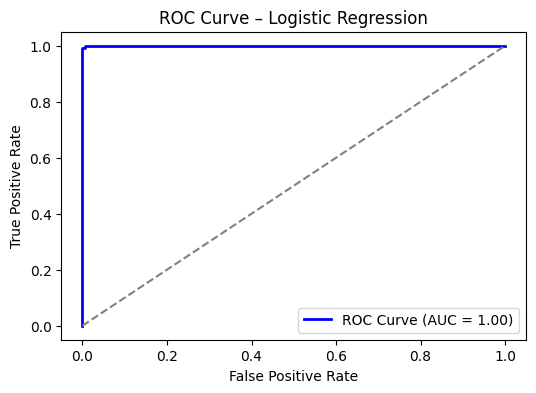

In [1]:
# ======================================
# Assignment 7 – Model Evaluation
# ======================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv("cleaned_ecommerce.csv")
df.columns = df.columns.str.strip()

# 2️⃣ Handle missing data
df = df.fillna(df.mean(numeric_only=True))

# 3️⃣ Select numeric columns
num_df = df.select_dtypes(include=["int64", "float64"])

# 4️⃣ Choose target variable
possible_targets = ["Gender", "Category", "Purchased", "Churn", "Label", "Target"]
target_var = None
for col in possible_targets:
    if col in df.columns:
        target_var = col
        break

if target_var is None:
    target_var = "Target"
    df[target_var] = np.where(num_df.iloc[:, -1] > num_df.iloc[:, -1].mean(), 1, 0)

print("🎯 Target variable:", target_var)

# 5️⃣ Define X and y
X = num_df.fillna(0)
y = df[target_var]

# 6️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7️⃣ Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8️⃣ Train models
log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

# 9️⃣ Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

# 🔟 Evaluation Metrics
models = {
    "Logistic Regression": (y_pred_lr, y_test),
    "Random Forest": (y_pred_rf, y_test)
}

print("\n📊 Model Evaluation Results:")
for name, (pred, actual) in models.items():
    print(f"\n{name}:")
    print(f"Accuracy:  {accuracy_score(actual, pred):.3f}")
    print(f"Precision: {precision_score(actual, pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(actual, pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(actual, pred, average='weighted'):.3f}")

# 🔢 Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ⚡ ROC Curve for Logistic Regression
if len(y.unique()) == 2:  # Only for binary classification
    y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve – Logistic Regression")
    plt.legend()
    plt.show()
